# ****Лабораторная работа №2****: ***Сегментация дорог с Аэрофотоснимков***

## Датасет

In [60]:
from pathlib import Path
from typing import Optional, List, Callable
import numpy as np
import torch
from torch.utils.data import Dataset
import tifffile
import random


class RoadsDataset(Dataset):
    def __init__(
        self,
        root: str,
        split: str = "train",
        image_transform: Optional[Callable] = None,
        mask_transform: Optional[Callable] = None,
        return_paths: bool = False,
        binarize_mask: bool = True,
    ):
        super().__init__()
        self.root = Path(root)
        self.split = split
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.return_paths = return_paths
        self.binarize_mask = binarize_mask

        self.images_dir = self.root / split
        self.masks_dir = self.root / f"{split}_labels"

        image_paths = sorted(self.images_dir.glob("*.tiff"))
        self.image_paths: List[Path] = []
        self.mask_map = {}

        for img_path in image_paths:
            mask_path = self.masks_dir / f"{img_path.stem}.tif"
            if mask_path.exists():
                self.image_paths.append(img_path)
                self.mask_map[img_path.stem] = mask_path

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        img_path = self.image_paths[idx]
        mask_path = self.mask_map[img_path.stem]

        image = tifffile.imread(str(img_path))
        mask = tifffile.imread(str(mask_path))

        if self.binarize_mask:
            if mask.ndim == 3:
                mask = mask[..., 0]
            mask = (mask > 0).astype(np.uint8)

        if self.image_transform is not None:
            if self.split == "train":
                seed = random.randint(0, 2**32 - 1)
                torch.manual_seed(seed)
                image = self.image_transform(image)

                torch.manual_seed(seed)
                mask = self.mask_transform(mask) if self.mask_transform is not None else mask
            else:
                image = self.image_transform(image)
                if self.mask_transform is not None:
                    mask = self.mask_transform(mask)

        mask = mask.float()

        if self.return_paths:
            return image, mask, str(img_path)
        return image, mask

In [ ]:
import torchvision.transforms as T

patch_size = 512
dataset_path = "roads_dataset/tiff"

train_image_transform = T.Compose([
    T.ToTensor(),
    T.RandomCrop(patch_size), 
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
])

train_mask_transform = T.Compose([
    T.ToTensor(),
    T.RandomCrop(patch_size),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
])

val_image_transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(patch_size), 
])

val_mask_transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(patch_size),
])

test_image_transform = T.Compose([
    T.ToTensor()
])

test_mask_transform = T.Compose([
    T.ToTensor()
])

# Датасеты
train_ds = RoadsDataset(root=dataset_path, split="train",
                        image_transform=train_image_transform,
                        mask_transform=train_mask_transform)

val_ds = RoadsDataset(root=dataset_path, split="val",
                      image_transform=val_image_transform,
                      mask_transform=val_mask_transform)

test_ds = RoadsDataset(root=dataset_path, split="test",
                       image_transform=test_image_transform,
                       mask_transform=test_mask_transform)

image, mask = train_ds[0]
print(f"Размер изображения: {image.shape}")
print(f"Размер маски: {mask.shape}")

print(f"Train размер: {len(train_ds)}")
print(f"Val размер: {len(val_ds)}")
print(f"Test размер: {len(test_ds)}")

Размер изображения: torch.Size([3, 512, 512])
Размер маски: torch.Size([1, 512, 512])
Train размер: 1108
Val размер: 14
Test размер: 49


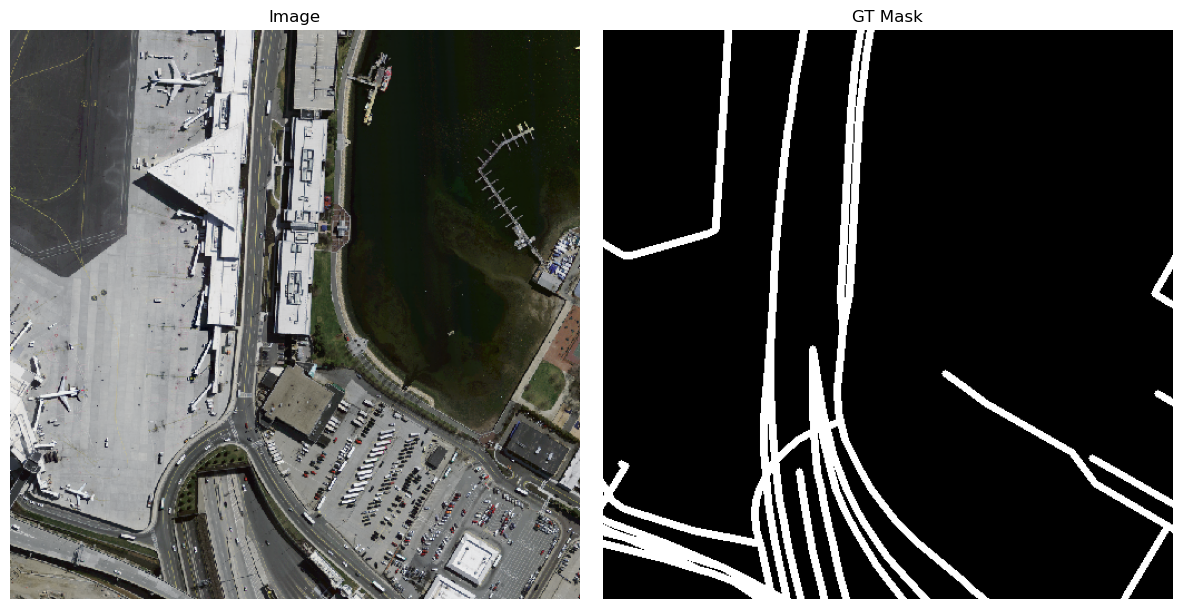

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([1, 512, 512])


In [62]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

images, masks = next(iter(train_loader))
image, mask = images[0], masks[0]


image_vis = image.permute(1, 2, 0).cpu().numpy()
mask_vis = mask.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_vis, cmap="gray")
axes[1].set_title("GT Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", image.shape if hasattr(image, "shape") else type(image))
print("Mask shape:", mask.shape if hasattr(mask, "shape") else type(mask))

# Модель, loss, optimizer

In [63]:
import torch
import torch.nn as nn
from tqdm import tqdm
import os

EPOCHS = 60
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"device: {DEVICE}")

device: cpu


In [67]:
import torch.optim as optim
from backboned_unet import Unet
from torchinfo import summary

model = Unet(
    backbone_name='vgg19', 
    pretrained=True, 
    encoder_freeze=False,
    classes=1,
    decoder_filters=(512, 256, 128, 64, 32)
).to(DEVICE)

print(model)
summary(model=model, input_size=(1, 3, 512, 512))


upsample_blocks[0] in: 512   out: 512
upsample_blocks[1] in: 512   out: 256
upsample_blocks[2] in: 256   out: 128
upsample_blocks[3] in: 128   out: 64
upsample_blocks[4] in: 64   out: 32
Unet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, mome

Layer (type:depth-idx)                   Output Shape              Param #
Unet                                     [1, 1, 512, 512]          --
├─Sequential: 1-1                        --                        --
│    └─Conv2d: 2-1                       [1, 64, 512, 512]         1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 512, 512]         128
│    └─ReLU: 2-3                         [1, 64, 512, 512]         --
│    └─Conv2d: 2-4                       [1, 64, 512, 512]         36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 512, 512]         128
│    └─ReLU: 2-6                         [1, 64, 512, 512]         --
│    └─MaxPool2d: 2-7                    [1, 64, 256, 256]         --
│    └─Conv2d: 2-8                       [1, 128, 256, 256]        73,856
│    └─BatchNorm2d: 2-9                  [1, 128, 256, 256]        256
│    └─ReLU: 2-10                        [1, 128, 256, 256]        --
│    └─Conv2d: 2-11                      [1, 128, 256, 256]        147,

In [ ]:
import segmentation_models_pytorch as smp

criterion = smp.losses.DiceLoss(mode="binary", from_logits=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5, 
    patience=5,
    verbose=True 
)

# Train цикл

In [ ]:
def train_epoch():
    model.train()
    running_loss = 0.0
    
    for images, masks in tqdm(train_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    return running_loss / len(train_loader)

@torch.no_grad()
def validate():
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    
    for images, masks in tqdm(val_loader, desc="Validation", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        
        logits = model(images)
        loss = criterion(logits, masks)
        
        running_loss += loss.item()
        
        tp, fp, fn, tn = smp.metrics.get_stats(logits, masks.long(), mode='binary', threshold=0.5)
        dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction='micro')
        running_dice += dice.item()
    
    avg_loss = running_loss / len(val_loader)
    avg_f1 = running_dice / len(val_loader)
    
    print(f"Dice (f1-score): {avg_f1:.4f}")
    return avg_loss, avg_f1

In [ ]:
best_dice = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch()
    val_loss, val_dice = validate()
    
    scheduler.step(val_dice)
    
    print(f"Epoch {epoch+1:3d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}")
    
    if val_dice > best_dice:
        best_dice = val_dice
        print(f"Обновлен best_dice: {best_dice}")
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'dice': best_dice,
        }, os.path.join(SAVE_DIR, "best_unet_vgg19bn_dice.pth"))

print(f"\nЛучший Dice на валидации = {best_dice:.4f} (эпоха {best_epoch})")

# Тест

In [ ]:
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F
import segmentation_models_pytorch as smp

model.eval()
test_dice = 0
num_samples = 0

patch_size = 512
stride = 256

with torch.no_grad():
    for i, (image, mask) in enumerate(test_loader):
        image = image.to(DEVICE)
        mask = mask.to(DEVICE)
        
        B, C, H, W = image.shape
        
        preds = torch.zeros((B, 1, H, W), device=DEVICE)
        counts = torch.zeros((B, 1, H, W), device=DEVICE)
        
        for y in range(0, H, stride):
            for x in range(0, W, stride):
                
                y1 = min(y, max(0, H - patch_size))
                x1 = min(x, max(0, W - patch_size))
                y2 = min(y1 + patch_size, H)
                x2 = min(x1 + patch_size, W)
                
                patch = image[:, :, y1:y2, x1:x2]
                
                pad_h = patch_size - patch.shape[2]
                pad_w = patch_size - patch.shape[3]
                if pad_h > 0 or pad_w > 0:
                    patch = F.pad(patch, (0, pad_w, 0, pad_h))
                
                logits = model(patch)
                
                if pad_h > 0 or pad_w > 0:
                    logits = logits[:, :, :patch.shape[2], :patch.shape[3]]
                
                preds[:, :, y1:y2, x1:x2] += logits
                counts[:, :, y1:y2, x1:x2] += 1
                
        output = preds / torch.clamp(counts, min=1)
        
        loss = criterion(output, mask)
        
        tp, fp, fn, tn = smp.metrics.get_stats(output, mask.long(), mode='binary', threshold=0.5)
        dice_score = smp.metrics.f1_score(tp, fp, fn, tn, reduction='micro').item()
        
        test_dice += dice_score
        num_samples += 1
        
        if i == 0:
            img_vis = image[0].permute(1, 2, 0).cpu().numpy()
            gt_vis = mask[0].squeeze().cpu().numpy()
            pred_vis = (torch.sigmoid(output[0]).squeeze() > 0.5).cpu().numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(img_vis)
            axes[0].set_title("Оригинал")
            axes[0].axis("off")

            axes[1].imshow(gt_vis, cmap="gray")
            axes[1].set_title("GT маска")
            axes[1].axis("off")

            axes[2].imshow(pred_vis, cmap="gray")
            axes[2].set_title("Предсказание по патчам")
            axes[2].axis("off")
            plt.show()

avg_test_dice = test_dice / num_samples
print(f'Avg Dice Score на тесте: {avg_test_dice:.4f}')

Average Dice Score on Test Set: 0.7260
